In [36]:
import numpy as np
import matplotlib.pyplot as plt


## Questão 1


## Questão 2 


In [37]:
def apply_reflector(v, beta, b):
    """Função que calcula Qb, onde Q = I - beta * vv* 

    Args:
        v (_type_): vetor que define a transformação de household
        beta (_type_): parâmetro que regula a transformação para manter Q ortogonal
        b (_type_): Vetor que estamos projetando 
    """
    n = len(v)                                          # Atribuição custo 1
    results = b.copy()                                  # Copia custo m = len(b)
    tail = results[-n:]                                 # Copia custo n = len(v)
    results[-n:] = tail - beta * (v.T @ tail) * v       # Produto interno + soma + multiplicação 4n 
    return results                                      # Complexibilidade final Max(m,n)

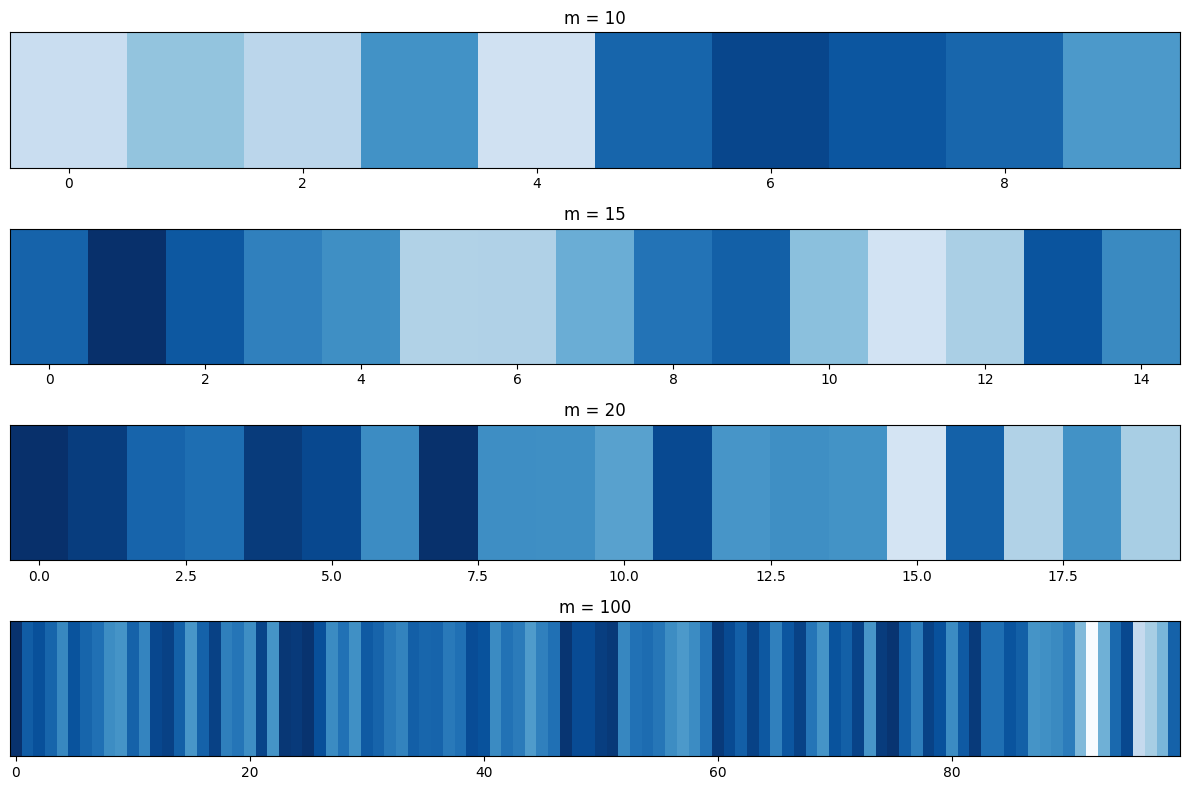

 Os valores do gráfico variam entre -1.358247579500308 e 0.9991720929552371


In [39]:
n = 10
m_s = [10, 15, 20, 100]
Qbs = []


for m in m_s:
    b = np.random.rand(m)
    v = np.random.rand(n)
    beta = 2 / (v @ v)
    Qb = apply_reflector(v, beta, b)
    Qbs.append(Qb)

vmin = min(np.min(q) for q in Qbs)
vmax = max(np.max(q) for q in Qbs)

fig, ax = plt.subplots(len(m_s), 1, figsize=(12, 8))

for i, (m, Qb) in enumerate(zip(m_s, Qbs)):

    im = ax[i].imshow(Qb.reshape(1, -1), aspect='auto', cmap='Blues', vmin=vmin, vmax=vmax)

    ax[i].set_title(f"m = {m}")
    ax[i].set_yticks([])


plt.tight_layout()
plt.show()

print(f" Os valores do gráfico variam entre {vmin} e {vmax}")
    


Como podemos análisar acima a função deu certo para vetores do mesmo tamanho e maiores que v. Reduzindo os valores do final de b. Aplicando corretamente a reflexão de Householder. 

A aplicação do refletor é realizada sem formar explicitamente a matriz Q. Utilizando a identidade

$$Qb=b−β(vTb)v$$

o custo é dominado por um produto interno e operações vetoriais, resultando em complexidade O(n), onde n é a dimensão do vetor de Householder. A implementação apresentada utiliza uma cópia do vetor de entrada para evitar modificações in-place, o que adiciona um custo O(m), onde m é a dimensão de b. Caso seja permitida a modificação direta do vetor de entrada, a implementação mantém complexidade O(n).